# Transformer example

This notebook builds a tiny **Transformer** whose attention is
constrained by a named edgelist.

The same building block appears in prior-gated attention as in
[Milia et al., 2026](https://doi.org/10.48550/arXiv.2606.09558)
(DOI: [10.48550/arXiv.2606.09558](https://doi.org/10.48550/arXiv.2606.09558)).
We do **not** reproduce their dataset, metrics, or results. The
point here is generic: an edgelist becomes the allow-set of
attention.

`kpnn2` does not ship a Transformer. You write the encoder, FFN,
residual, pooling, and head in PyTorch.
`PackedMultiheadAttention` is the primitive that scores only live
edgelist pairs. There is no `parse_attention()`.
`parse_adjacency()` already returns the packed indices.

It assumes you have already read
[Feedforward example](../feedforward-example/). That tutorial is a
feedforward `MaskedLinear` KPNN. Here every node is a token and
the prior is an attention allow-set, not a hop mask.


In [1]:
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2

In [2]:
from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 14
_FIG_W = 7.0
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)
sns.set_theme(
    style="ticks",
    rc=_plot_rc,
)


def _new_fig(height):
    return plt.figure(figsize=(_FIG_W, height))


def _style_ax(ax):
    ax.tick_params(labelsize=_FONT_SIZE)
    ax.title.set_fontsize(_FONT_SIZE)
    ax.xaxis.label.set_size(_FONT_SIZE)
    ax.yaxis.label.set_size(_FONT_SIZE)
    ax.set_facecolor("none")
    ax.grid(False)

## Define the graph

Two hidden nodes gather from disjoint input sets:

- `input_signal_*` feed `node_a` (informative later)
- `input_noise_*` feed `node_b` (uninformative later)

The edgelist format is the same two columns as
[Feedforward example](../feedforward-example/): `source` and
`target`. In `kpnn2`, a row means **source feeds target**. For
attention that is **query = target, key/value = source**, so
`node_a` attends to its signal inputs. That is the same arrow
as a KPNN linear layer.

A table written as query → key is the opposite column order.
Swap `source` and `target` before parsing if you want this
gathering convention.

This graph is a DAG, so `parse_layered()` would accept it. Use
`parse_adjacency()` anyway: every node is one token in a single
sequence. Do not pass a hop mask to
`PackedMultiheadAttention`.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "input_signal_1",
            "input_signal_2",
            "input_signal_3",
            "input_noise_1",
            "input_noise_2",
            "input_noise_3",
        ],
        "target": [
            "node_a",
            "node_a",
            "node_a",
            "node_b",
            "node_b",
            "node_b",
        ],
    }
)

spec = kpnn2.parse_adjacency(edgelist)
edgelist

,source,target
0,input_signal_1,node_a
1,input_signal_2,node_a
2,input_signal_3,node_a
3,input_noise_1,node_b
4,input_noise_2,node_b
5,input_noise_3,node_b


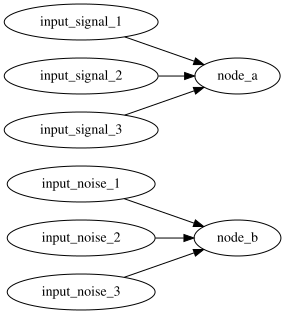

In [4]:
dot = Digraph()
dot.attr(rankdir="LR")

with dot.subgraph() as s:
    s.attr(rank="same")
    for name in spec.input_nodes:
        s.node(name, name)

with dot.subgraph() as s:
    s.attr(rank="same")
    for name in spec.output_nodes:
        s.node(name, name)

for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))

dot

`parse_adjacency()` puts every node in one alphabetical sequence
and packs the live pairs. Measured features are in-degree 0
(`input_nodes`). Gather nodes are out-degree 0
(`output_nodes`). Those roles are graph structure, not "only
inputs are tokens": both are tokens. The input role only tells
us which columns `align_inputs()` returns.

`add_self_loops=True` below ORs missing `(i, i)` pairs into the
layer so isolated queries (the input tokens) are not forced to
zero. `need_weights=True` is rejected: returning a dense
`(L, S)` weight matrix is exactly what this primitive must not
allocate, so we will not plot attention maps.


In [5]:
n_nodes = len(spec.nodes)
spec.nodes, spec.input_nodes, spec.output_nodes

(('input_noise_1',
  'input_noise_2',
  'input_noise_3',
  'input_signal_1',
  'input_signal_2',
  'input_signal_3',
  'node_a',
  'node_b'),
 ('input_noise_1',
  'input_noise_2',
  'input_noise_3',
  'input_signal_1',
  'input_signal_2',
  'input_signal_3'),
 ('node_a', 'node_b'))

## Write a Transformer around PackedMultiheadAttention

The encoder is ordinary PyTorch: feature projection, a learned
identity embedding per named node, Pre-LN packed attention, a
token-wise FFN, and residuals. The classification head reads
only the gather tokens (`spec.output_index`).

`align_inputs()` is still the named input-table helper. It is
`len(input_nodes)` wide, not `n_nodes` wide. Scatter those
columns into the token sequence with `spec.input_index` before
attention. Gather-node positions stay zero: they are not
measured features; they collect input values through the prior.


In [6]:
class TokenEncoder(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        embed_dim: int,
        num_heads: int,
    ):
        super().__init__()
        self.spec = spec
        n_nodes = len(spec.nodes)
        self.expr_proj = nn.Linear(
            1,
            embed_dim,
        )
        self.id_embed = nn.Embedding(
            n_nodes,
            embed_dim,
        )
        self.attn = kpnn2.PackedMultiheadAttention(
            spec.source_index,
            spec.target_index,
            n_nodes,
            n_nodes,
            embed_dim,
            num_heads,
            add_self_loops=True,
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(
                embed_dim,
                2 * embed_dim,
            ),
            nn.ReLU(),
            nn.Linear(
                2 * embed_dim,
                embed_dim,
            ),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        n_nodes = len(self.spec.nodes)
        tokens = self.expr_proj(x.unsqueeze(-1))
        node_ids = torch.arange(
            n_nodes,
            device=x.device,
        )
        tokens = tokens + self.id_embed(node_ids)
        normed = self.norm1(tokens)
        attended, _ = self.attn(
            normed,
            normed,
            normed,
        )
        tokens = tokens + attended
        tokens = tokens + self.ffn(self.norm2(tokens))
        return tokens


class PriorTransformer(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        embed_dim: int = 8,
        num_heads: int = 2,
    ):
        super().__init__()
        self.spec = spec
        self.encoder = TokenEncoder(
            spec,
            embed_dim,
            num_heads,
        )
        n_out = len(spec.output_index)
        self.head = nn.Linear(
            n_out * embed_dim,
            1,
        )

    def forward(self, x_inputs):
        n_nodes = len(self.spec.nodes)
        state = x_inputs.new_zeros(
            x_inputs.shape[0],
            n_nodes,
        )
        state[:, self.spec.input_index] = x_inputs
        encoded = self.encoder(state)
        node_tokens = encoded[:, self.spec.output_index]
        pooled = node_tokens.reshape(
            node_tokens.shape[0],
            -1,
        )
        return self.head(pooled)

In [7]:
model = PriorTransformer(spec)
(
    n_nodes,
    model.encoder.attn.nnz,
    spec.source_index,
    spec.target_index,
)

(8, 14, (0, 1, 2, 3, 4, 5), (7, 7, 7, 6, 6, 6))

## Simulate data, align features, and train

Same binary toy pattern as
[Feedforward example](../feedforward-example/): `input_signal_*`
change mean between classes, `input_noise_*` do not. 100 samples
per class for training, 50 for testing.


In [8]:
informative_features = [
    "input_signal_1",
    "input_signal_2",
    "input_signal_3",
]
noise_features = [
    "input_noise_1",
    "input_noise_2",
    "input_noise_3",
]
all_features = informative_features + noise_features

n_train_per_class = 100
n_test_per_class = 50
rng = np.random.default_rng(42)


def simulate_binary_classification_data(n_per_class, rng):
    x0_signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x1_signal = rng.normal(
        loc=2.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x0_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x1_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x0 = np.concatenate([x0_signal, x0_noise], axis=1)
    x1 = np.concatenate([x1_signal, x1_noise], axis=1)
    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )
    permutation = rng.permutation(len(y))
    x = x[permutation]
    y = y[permutation]
    x_df = pd.DataFrame(x, columns=all_features)
    y_series = pd.Series(y, name="label")
    return x_df, y_series


x_train_df, y_train = simulate_binary_classification_data(
    n_per_class=n_train_per_class,
    rng=rng,
)
x_test_df, y_test = simulate_binary_classification_data(
    n_per_class=n_test_per_class,
    rng=rng,
)

x_train = kpnn2.align_inputs(x_train_df, spec)
x_test = kpnn2.align_inputs(x_test_df, spec)
display(x_train_df.head())
x_train.shape, x_test.shape, len(spec.nodes)

,input_signal_1,input_signal_2,input_signal_3,input_noise_1,input_noise_2,input_noise_3
0,-0.695943,-0.223859,0.242497,-1.139429,-0.481241,1.437777
1,3.068472,2.232878,2.234401,-0.712102,1.370541,-0.484030
2,-0.471525,0.263717,0.052467,0.288917,1.244947,-0.431339
3,0.941464,1.874991,3.481456,-0.109727,-0.035611,-1.364742
4,-0.926576,-0.389810,-1.376686,-1.119536,0.447814,0.058274


(torch.Size([200, 6]), torch.Size([100, 6]), 8)

Loss before first update: 0.6977
Loss after final update:  0.1122
Test accuracy: 0.92


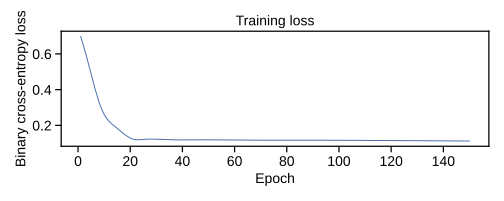

In [9]:
y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []
model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

model.eval()
with torch.no_grad():
    pred = (torch.sigmoid(model(x_test))[:, 0] > 0.5).float()
    y_test_tensor = torch.tensor(
        y_test.values,
        dtype=torch.float32,
    )
    test_acc = float((pred == y_test_tensor).float().mean())

print(
    "Loss before first update:",
    round(loss_history[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history[-1], 4),
)
print("Test accuracy:", round(test_acc, 3))

_new_fig(2.8)
plt.plot(
    range(1, n_epochs + 1),
    loss_history,
    linewidth=1,
)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Interpret named nodes

`kpnn2` does not wrap Captum. Feature scores use
`IntegratedGradients` on the input tensor from `align_inputs()`.
Node scores use `LayerConductance` on the encoder, whose output
is `(batch, n_nodes, embed_dim)`. Sum the embed axis so the
remaining width is `spec.nodes`, then
`map_node_attributions()` (no `layer=`: this is an
`AdjacencySpec`). See
[Mapping attributions](../map-node-attributions/).

Input tokens are not read by the head, so encoder conductance on
those positions is zero. The gather tokens should not be:
`node_a` collects the informative inputs.


In [ ]:
from captum.attr import (
    IntegratedGradients,
    LayerConductance,
)

model.eval()
ig = IntegratedGradients(model)
feature_tensor = ig.attribute(
    x_test,
    target=0,
)
feature_attr = pd.DataFrame(
    feature_tensor.detach().cpu().numpy(),
    columns=spec.input_nodes,
)
feature_summary = (
    feature_attr.abs()
    .mean()
    .rename("mean_abs_attribution")
    .sort_values(ascending=False)
    .to_frame()
)
feature_summary

,mean_abs_attribution
input_signal_3,3.036364
input_signal_1,1.632125
input_signal_2,1.467717
input_noise_2,0.050085
input_noise_1,0.047762
input_noise_3,0.035458


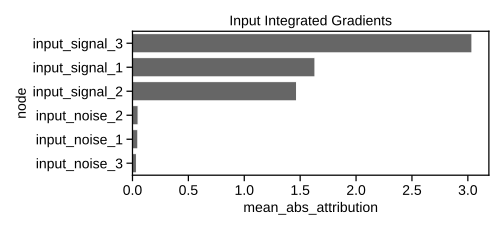

In [11]:
_new_fig(3.2)
ax = sns.barplot(
    data=feature_summary.reset_index().rename(columns={"index": "node"}),
    x="mean_abs_attribution",
    y="node",
    color="0.4",
)
_style_ax(ax)
ax.set_title("Input Integrated Gradients")
plt.tight_layout()
plt.show()

In [12]:
conductor = LayerConductance(
    model,
    model.encoder,
)
token_attr = conductor.attribute(
    x_test,
    target=0,
)
node_scores = token_attr.detach().abs().sum(dim=-1)
node_attr = kpnn2.map_node_attributions(
    attributions=node_scores,
    spec=spec,
)
node_summary = (
    node_attr.to_pandas()
    .mean()
    .rename("mean_abs_attribution")
    .sort_values(ascending=False)
    .to_frame()
)
node_summary

,mean_abs_attribution
node,
node_a,5.501344
node_b,0.256008
input_noise_1,0.000000
input_noise_2,0.000000
input_signal_1,0.000000
input_noise_3,0.000000
input_signal_3,0.000000
input_signal_2,0.000000


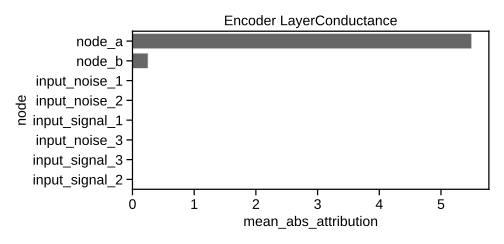

In [13]:
_new_fig(3.4)
ax = sns.barplot(
    data=node_summary.reset_index(),
    x="mean_abs_attribution",
    y="node",
    color="0.4",
)
_style_ax(ax)
ax.set_title("Encoder LayerConductance")
plt.tight_layout()
plt.show()

## Control: rewire the prior

Keep the same samples and labels. Point the signal inputs at
`node_b` and the noise inputs at `node_a`. If the named graph is
the inductive bias, `node_b` should now carry the task.


In [14]:
rewired = pd.DataFrame(
    {
        "source": [
            "input_signal_1",
            "input_signal_2",
            "input_signal_3",
            "input_noise_1",
            "input_noise_2",
            "input_noise_3",
        ],
        "target": [
            "node_b",
            "node_b",
            "node_b",
            "node_a",
            "node_a",
            "node_a",
        ],
    }
)
rewired_spec = kpnn2.parse_adjacency(rewired)
torch.manual_seed(42)
rewired_model = PriorTransformer(rewired_spec)

optimizer = torch.optim.Adam(
    rewired_model.parameters(),
    lr=1e-2,
    weight_decay=1e-2,
)
rewired_model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = rewired_model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

rewired_model.eval()
rewired_scores = (
    LayerConductance(
        rewired_model,
        rewired_model.encoder,
    )
    .attribute(
        x_test,
        target=0,
    )
    .detach()
    .abs()
    .sum(dim=-1)
)
rewired_summary = (
    kpnn2.map_node_attributions(
        attributions=rewired_scores,
        spec=rewired_spec,
    )
    .to_pandas()
    .mean()
    .rename("rewired")
)
compare = pd.concat(
    [
        node_summary["mean_abs_attribution"].rename("original"),
        rewired_summary,
    ],
    axis=1,
).loc[["node_a", "node_b"]]
compare

,original,rewired
node,,
node_a,5.501344,0.588435
node_b,0.256008,4.813887


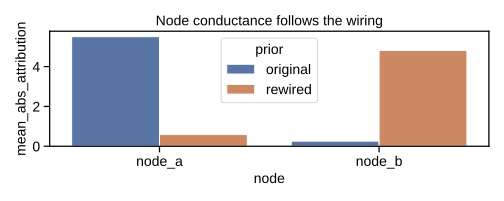

In [15]:
plot_df = compare.reset_index().melt(
    id_vars="node",
    var_name="prior",
    value_name="mean_abs_attribution",
)
_new_fig(2.8)
ax = sns.barplot(
    data=plot_df,
    x="node",
    y="mean_abs_attribution",
    hue="prior",
)
_style_ax(ax)
ax.set_title("Node conductance follows the wiring")
plt.tight_layout()
plt.show()

## What this page leaves out

Milia et al. train on a large atlas with extra machinery
(variable-length tokens, sparse host batching, sinusoidal
encodings, attention-map metrics). None of that is in `kpnn2`,
and none of it is repeated here.

`key_padding_mask` is the analogue of "this input is absent in
this sample": a boolean mask over keys, applied in packed
space. Host-sparse storage (for example AnnData `.X`) stays in
the caller's loop; tensors that enter the module are dense.

`PackedLinear` is a different primitive (one scalar per edge,
not attention). See [PackedLinear](../packed_linear/) when the
adjacency square would hurt RAM, and the
[Cyclic graph example](../cyclic-graph-example/) for a cyclic
`MaskedLinear` state update. The API page is
[PackedMultiheadAttention](../reference/PackedMultiheadAttention/).
